In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_DIR = Path("./outputs")
OUT_DIR = Path("./outputs/agg")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pattern = "*.csv"
files = sorted(IN_DIR.glob(pattern))
len(files)

144

In [3]:
dfs = []
for fp in files:
    df = pd.read_csv(fp)

    if not {"dataset", "method", "mode", "seed"}.issubset(df.columns):
        m = re.match(r"(.+?)__(.+?)__(.+?)__run(.+?)__(.+?)__seed(\d+)__filtering(.+?)\.csv", fp.name)
        if m:
            df.insert(0, "dataset", m.group(1))
            df.insert(1, "method", m.group(2))
            df.insert(2, "mode", m.group(3))
            df.insert(3, "run", m.group(4))
            df.insert(4, "sample", m.group(5))
            df.insert(5, "seed", int(m.group(6)))
            df.insert(6, 'fliter', m.group(7))
        else:
            raise ValueError(f"Missing meta columns and cannot parse filename: {fp.name}")

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

In [4]:
all_df[all_df['filtering']==False]

,dataset,method,mode,run,sample,seed,test_ratio,filtering,aug_ratio,cutoff,mse,mae,mape,syn_ratio
0,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,False,0.0,2014-09-19,7.711309e+03,55.546448,7.743293e+15,NaN
1,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,False,0.1,2014-09-19,8.336849e+03,57.455555,8.024368e+15,NaN
2,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,False,0.2,2014-09-19,8.375984e+03,58.088993,8.055265e+15,NaN
3,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,False,0.3,2014-09-19,8.748094e+03,58.613022,8.730216e+15,NaN
4,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,False,0.4,2014-09-19,9.092898e+03,59.889271,9.629725e+15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1568,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,False,NaN,2011-12-30,5.977372e+08,16426.277010,8.405417e+01,0.6
1569,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,False,NaN,2011-12-30,3.419651e+08,13397.318588,6.729747e+01,0.7
1570,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,False,NaN,2011-12-30,1.448699e+09,25985.793919,1.055589e+02,0.8
1571,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,False,NaN,2011-12-30,6.125626e+08,17589.416791,9.032890e+01,0.9


In [5]:
all_df[all_df['filtering']==True]

,dataset,method,mode,run,sample,seed,test_ratio,filtering,aug_ratio,cutoff,mse,mae,mape,syn_ratio
11,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,True,0.0,2014-09-19,7.711309e+03,55.546448,7.743293e+15,NaN
12,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,True,0.1,2014-09-19,8.336849e+03,57.455555,8.024368e+15,NaN
13,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,True,0.2,2014-09-19,8.375984e+03,58.088993,8.055265e+15,NaN
14,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,True,0.3,2014-09-19,8.748094e+03,58.613022,8.730216e+15,NaN
15,rossmann_subsampled,CLAVADDPM,tatr,1,sample1,1,0.2,True,0.4,2014-09-19,9.092898e+03,59.889271,9.629725e+15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,True,NaN,2011-12-30,6.263081e+08,15919.459543,5.386887e+01,0.6
1580,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,True,NaN,2011-12-30,6.156231e+08,15517.511316,7.154935e+01,0.7
1581,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,True,NaN,2011-12-30,8.196152e+08,18885.641849,6.313318e+01,0.8
1582,walmart_subsampled,SDV,tmtr,1,sample1,3,0.2,True,NaN,2011-12-30,1.144108e+09,19687.280926,7.143019e+01,0.9


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def aggregate_all_methods(agg_df: pd.DataFrame, mode='tatr', dataset='rossmann'):
    # 1. Dataset과 Mode만 필터링 (Method는 모두 포함)
    filtered = agg_df[(agg_df['dataset'] == dataset) & (agg_df['mode'] == mode)]
    
    # 2. X축 컬럼 설정 (mode에 따라 변경)
    x_col = 'aug_ratio' if mode == 'tatr' else 'syn_ratio'
    
    group_cols = ['method', x_col]
    metric_cols = ['mse', 'mae', 'mape']
    
    # 4. 집계 (Mean, Std)
    # groupby에 'method'가 추가됨 -> method별, ratio별 통계가 나옴
    agg_result = filtered.groupby(group_cols)[metric_cols].agg(['mean', 'std']).reset_index()
    
    return agg_result, x_col

# 사용 예시
DATASET = 'rossmann_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def aggregate_all_methods(agg_df: pd.DataFrame, mode='tatr', dataset='rossmann'):
    # 1. Dataset과 Mode만 필터링 (Method, Filtering 여부는 모두 포함)
    filtered = agg_df[(agg_df['dataset'] == dataset) & (agg_df['mode'] == mode)]
    
    # 2. X축 컬럼 설정 (mode에 따라 변경)
    x_col = 'aug_ratio' if mode == 'tatr' else 'syn_ratio'
    
    # 3. 필요한 컬럼만 추출
    # [수정] 그룹핑 기준에 'filtering' 추가 -> 필터링 적용 여부별로 따로 통계 계산
    group_cols = ['method', 'filtering', x_col]
    metric_cols = ['mse', 'mae', 'mape']
    
    # 4. 집계 (Mean, Std)
    # 이제 (모델, 필터링여부, 비율) 조합별로 평균/표준편차가 계산됨
    agg_result = filtered.groupby(group_cols)[metric_cols].agg(['mean', 'std']).reset_index()
    
    return agg_result, x_col

# --- 사용 예시 ---
DATASET = 'rossmann_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'

# 1. 집계 수행
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

In [8]:
final_df

method filtering aug_ratio          mse                    mae  \
                                           mean         std       mean   
0    CLAVADDPM     False       0.0  7711.308594    0.000000  55.546448   
1    CLAVADDPM     False       0.1  8279.694824  107.072765  57.248466   
2    CLAVADDPM     False       0.2  8549.991536  272.699006  58.367073   
3    CLAVADDPM     False       0.3  8809.201823   54.044528  58.884118   
4    CLAVADDPM     False       0.4  9040.833659   48.621723  59.666177   
..         ...       ...       ...          ...         ...        ...   
127        SDV      True       0.6  8413.347982   69.409485  56.486163   
128        SDV      True       0.7  8734.216146   97.069104  57.572735   
129        SDV      True       0.8  8406.404785  213.269865  56.974215   
130        SDV      True       0.9  8816.951497  103.892117  57.425715   
131        SDV      True       1.0  8777.634115   73.592985  57.601509   

                       mape                
          std          mean           std  
0    0.000000  7.743293e+15  0.000000e+00  
1    0.193935  8.003948e+15  6.591194e+14  
2    0.440618  8.195256e+15  2.158972e+14  
3    0.329745  8.609286e+15  5.186136e+14  
4    0.221843  9.319607e+15  2.826974e+14  
..        ...           ...           ...  
127  0.495204  7.884193e+15  4.159713e+14  
128  0.277885  8.545898e+15  5.724474e+14  
129  0.511230  8.495313e+15  3.727939e+14  
130  0.313674  7.861092e+15  3.367983e+14  
131  0.266734  8.555717e+15  1.963588e+14  

[132 rows x 9 columns]

In [9]:
DATASET = 'walmart_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'

# 1. 집계 수행
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

In [10]:
final_df

method filtering aug_ratio           mse                         mae  \
                                            mean           std          mean   
0    CLAVADDPM     False       0.0  9.801238e+08  0.000000e+00  16370.293667   
1    CLAVADDPM     False       0.1  6.905880e+08  2.974284e+08  15444.404649   
2    CLAVADDPM     False       0.2  6.986063e+08  3.881501e+07  14812.566172   
3    CLAVADDPM     False       0.3  7.006410e+08  8.255481e+07  14130.143862   
4    CLAVADDPM     False       0.4  6.525859e+08  4.144570e+07  14586.351858   
..         ...       ...       ...           ...           ...           ...   
127        SDV      True       0.6  5.764319e+08  2.379200e+08  15185.293655   
128        SDV      True       0.7  6.750406e+08  1.473128e+08  14900.928694   
129        SDV      True       0.8  6.764860e+08  1.939521e+08  15813.719916   
130        SDV      True       0.9  5.358600e+08  1.312393e+08  15172.843591   
131        SDV      True       1.0  6.144461e+08  7.059826e+07  15605.250454   

                       mape             
             std       mean        std  
0       0.000000   6.129590   0.000000  
1    4167.786822  31.988092  10.906501  
2     474.513193  22.086126   3.493967  
3     931.345538  23.436158   2.912080  
4      61.413252  27.052696   4.513278  
..           ...        ...        ...  
127  2567.568789  57.588614  10.003699  
128  1129.167943  42.981175   7.527707  
129  1316.552897  51.724221  14.619331  
130   445.268852  60.709527  16.028100  
131  1543.135823  60.179655  12.091666  

[132 rows x 9 columns]

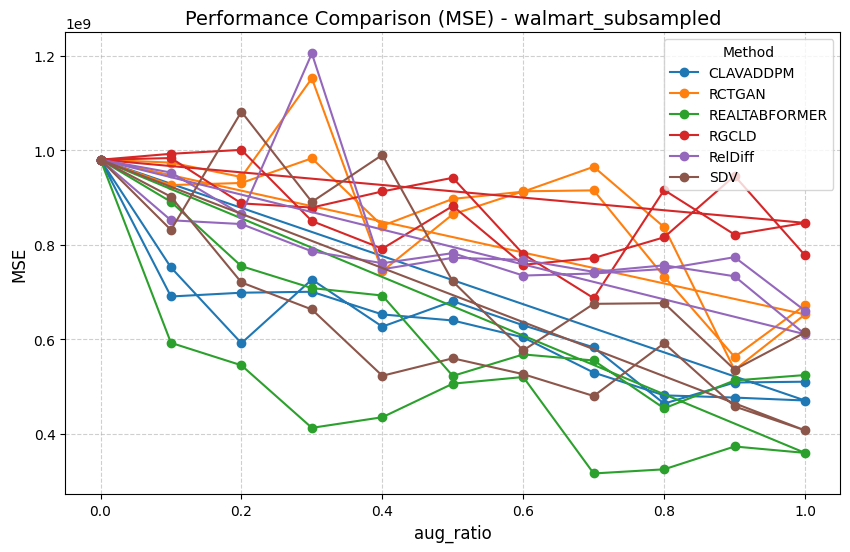

In [11]:
def plot_performance(agg_result, x_col, metric='mse', title_suffix=''):
    """
    agg_result: 위에서 집계한 DataFrame
    x_col: 'aug_ratio' 또는 'syn_ratio'
    metric: 그릴 지표 ('mse', 'mae', 'mape')
    """
    
    plt.figure(figsize=(10, 6))
    
    # 유니크한 method 리스트 추출
    methods = agg_result['method'].unique()
    
    # 각 Method별로 반복하며 그리기
    for method in methods:
        # 해당 method의 데이터만 추출
        subset = agg_result[agg_result['method'] == method]
        
        # X축: ratio, Y축: 평균값
        x = subset[x_col]
        y_mean = subset[metric]['mean']
        y_std = subset[metric]['std']
        
        # 메인 선 그래프 (평균)
        line, = plt.plot(x, y_mean, label=method, marker='o')
        
        # # 오차 범위 (표준편차) 음영 처리
        # plt.fill_between(
        #     x, 
        #     y_mean - y_std, 
        #     y_mean + y_std, 
        #     color=line.get_color(), 
        #     alpha=0.2  # 투명도 조절
        # )

    # 그래프 스타일 설정
    plt.title(f'Performance Comparison ({metric.upper()}) - {title_suffix}', fontsize=14)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(metric.upper(), fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Method')
    
    plt.show()

final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

# 2. 그래프 그리기 (MSE 기준)
plot_performance(final_df, x_axis_name, metric='mse', title_suffix=DATASET)

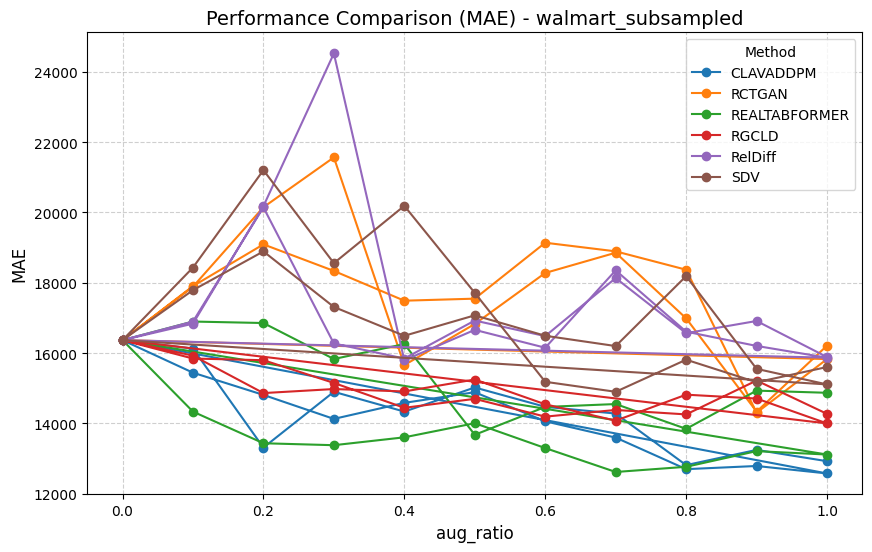

In [12]:
DATASET = 'walmart_subsampled'
MODE = 'tatr'  # 혹은 'tmtr'
final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)
plot_performance(final_df, x_axis_name, metric='mae', title_suffix=DATASET)

In [13]:
final_df[final_df['aug_ratio']==0.0]

method filtering aug_ratio           mse                mae       \
                                                mean  std          mean  std   
0        CLAVADDPM     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
11       CLAVADDPM      True       0.0  9.801238e+08  0.0  16370.293667  0.0   
22          RCTGAN     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
33          RCTGAN      True       0.0  9.801238e+08  0.0  16370.293667  0.0   
44   REALTABFORMER     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
55   REALTABFORMER      True       0.0  9.801238e+08  0.0  16370.293667  0.0   
66           RGCLD     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
77           RGCLD      True       0.0  9.801238e+08  0.0  16370.293667  0.0   
88         RelDiff     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
99         RelDiff      True       0.0  9.801238e+08  0.0  16370.293667  0.0   
110            SDV     False       0.0  9.801238e+08  0.0  16370.293667  0.0   
121            SDV      True       0.0  9.801238e+08  0.0  16370.293667  0.0   

        mape       
        mean  std  
0    6.12959  0.0  
11   6.12959  0.0  
22   6.12959  0.0  
33   6.12959  0.0  
44   6.12959  0.0  
55   6.12959  0.0  
66   6.12959  0.0  
77   6.12959  0.0  
88   6.12959  0.0  
99   6.12959  0.0  
110  6.12959  0.0  
121  6.12959  0.0

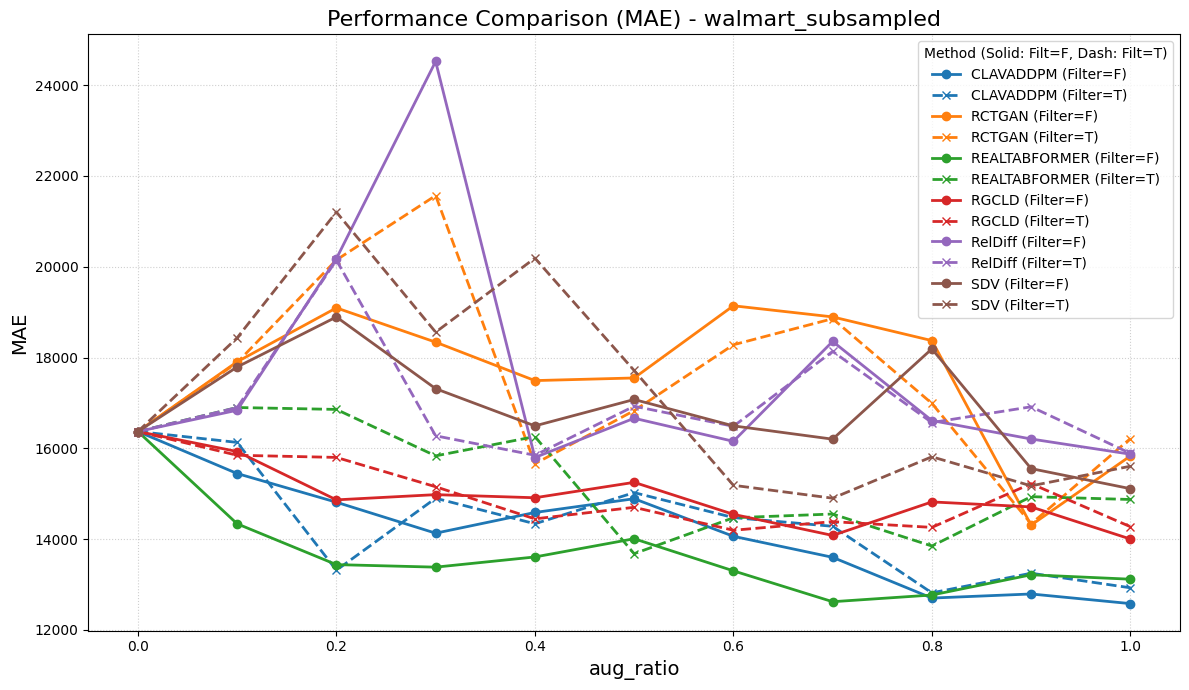

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_performance(agg_result, x_col, metric='mse', title_suffix=''):
    """
    agg_result: aggregate_all_methods를 통해 집계된 DataFrame (method, filtering 컬럼 포함)
    x_col: 'aug_ratio' 또는 'syn_ratio'
    metric: 그릴 지표 ('mse', 'mae', 'mape')
    """
    
    plt.figure(figsize=(12, 7))
    
    # 1. 고유한 Method 리스트 추출 (색상 고정을 위해)
    methods = agg_result['method'].unique()
    
    # 2. 색상 맵 설정 (Method별 고유 색상)
    # tab10 컬러맵을 사용하여 각 method에 색상 할당
    cmap = plt.get_cmap('tab10')
    method_colors = {m: cmap(i) for i, m in enumerate(methods)}
    
    # 3. 선 스타일 설정 (Filtering 여부에 따라)
    # False(추천)는 실선, True(기존)는 점선
    line_styles = {False: '-', True: '--'}
    marker_styles = {False: 'o', True: 'x'} # 마커도 구분 (선택사항)

    # 4. 루프: Method -> Filtering 순서로 반복
    for method in methods:
        # 해당 Method의 색상 가져오기
        c = method_colors[method]
        
        for filt in [False, True]: # False 먼저 그리기 (범례 순서 고려)
            # 데이터 필터링: (Specific Method) & (Specific Filtering)
            subset = agg_result[
                (agg_result['method'] == method) & 
                (agg_result['filtering'] == filt)
            ]
            
            # 해당 조건의 데이터가 없으면 건너뜀 (예: SDV + Filt=True로 에러나서 데이터 없는 경우)
            if subset.empty:
                continue
            
            # X축 정렬 (선 그래프가 꼬이지 않도록)
            subset = subset.sort_values(by=x_col)
            
            # 데이터 추출
            x = subset[x_col]
            y_mean = subset[metric]['mean']
            y_std = subset[metric]['std']
            
            # 범례 라벨 생성
            filt_label = "Filter=T" if filt else "Filter=F"
            label = f"{method} ({filt_label})"
            
            # 그래프 그리기
            line, = plt.plot(
                x, y_mean, 
                label=label, 
                color=c,                    # Method별 색상
                linestyle=line_styles[filt], # Filtering별 선 스타일
                marker=marker_styles[filt],  # Filtering별 마커
                linewidth=2,
                markersize=6
            )
            
            # 오차 범위 (표준편차) 음영 처리 (필요시 주석 해제)
            # plt.fill_between(
            #     x, 
            #     y_mean - y_std, 
            #     y_mean + y_std, 
            #     color=c, 
            #     alpha=0.1 if filt else 0.2 # False일 때 좀 더 진하게
            # )

    # 그래프 스타일 설정
    plt.title(f'Performance Comparison ({metric.upper()}) - {title_suffix}', fontsize=16)
    plt.xlabel(x_axis_name, fontsize=14)
    plt.ylabel(metric.upper(), fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 범례 설정 (그래프 밖으로 뺄 수도 있음)
    plt.legend(title='Method (Solid: Filt=F, Dash: Filt=T)', fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()

final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)

# 2. 그래프 그리기 (MSE 기준)
plot_performance(final_df, x_axis_name, metric='mae', title_suffix=DATASET)

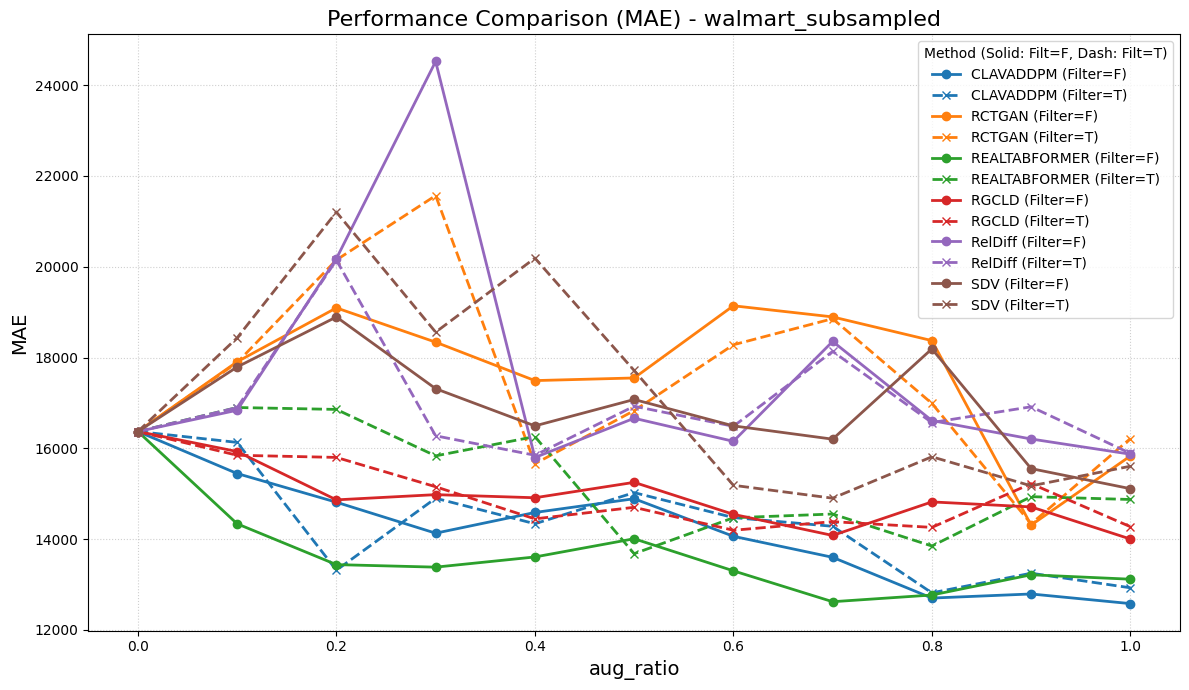

In [20]:
MODE = 'tatr'
DATASET = 'walmart_subsampled'

final_df, x_axis_name = aggregate_all_methods(all_df, mode=MODE, dataset=DATASET)
plot_performance(final_df, x_axis_name, metric='mae', title_suffix=DATASET)

In [18]:
final_df[final_df['method']=='SDV']

method filtering syn_ratio            mse                      mae  \
                                         mean          std        mean   
110    SDV     False       0.0    8031.707194    47.712222   56.335313   
111    SDV     False       0.1    9756.850911  1085.664776   58.043579   
112    SDV     False       0.2   10943.149089  2540.732863   60.879889   
113    SDV     False       0.3   11638.521810  2006.803058   62.375743   
114    SDV     False       0.4   13021.749674  1727.764535   62.963713   
115    SDV     False       0.5   13405.269857  1969.250163   65.263313   
116    SDV     False       0.6   12396.187826   437.311530   64.945999   
117    SDV     False       0.7   20791.035482  9591.118071   71.110352   
118    SDV     False       0.8   22352.446615  1648.118831   82.074453   
119    SDV     False       0.9   35839.718750  7828.229026   98.742109   
120    SDV     False       1.0  465349.395833  7371.046697  547.835449   
121    SDV      True       0.0    8031.707194    47.712222   56.335313   
122    SDV      True       0.1    9756.850911  1085.664776   58.043579   
123    SDV      True       0.2   10943.149089  2540.732863   60.879889   
124    SDV      True       0.3   11638.521810  2006.803058   62.375743   
125    SDV      True       0.4   13021.749674  1727.764535   62.963713   
126    SDV      True       0.5   13405.269857  1969.250163   65.263313   
127    SDV      True       0.6   12396.187826   437.311530   64.945999   
128    SDV      True       0.7   20791.035482  9591.118071   71.110352   
129    SDV      True       0.8   22352.446615  1648.118831   82.074453   
130    SDV      True       0.9   35839.718750  7828.229026   98.742109   
131    SDV      True       1.0  465349.395833  7371.046697  547.835449   

                       mape                
          std          mean           std  
110  0.386425  7.797893e+15  3.520738e+14  
111  0.426787  9.283799e+15  3.694870e+14  
112  1.901564  1.224568e+16  1.361195e+15  
113  2.078301  1.123213e+16  1.036113e+15  
114  0.880804  1.182063e+16  6.838848e+14  
115  1.941515  1.380906e+16  1.830003e+15  
116  0.227353  1.360768e+16  8.070566e+14  
117  4.618495  1.666984e+16  4.877620e+15  
118  2.486263  2.319005e+16  1.674272e+15  
119  6.462252  3.612608e+16  8.835605e+15  
120  7.661142  4.599306e+16  6.923399e+15  
121  0.386425  7.797893e+15  3.520738e+14  
122  0.426787  9.283799e+15  3.694870e+14  
123  1.901564  1.224568e+16  1.361195e+15  
124  2.078301  1.123213e+16  1.036113e+15  
125  0.880804  1.182063e+16  6.838848e+14  
126  1.941515  1.380906e+16  1.830003e+15  
127  0.227353  1.360768e+16  8.070566e+14  
128  4.618495  1.666984e+16  4.877620e+15  
129  2.486263  2.319005e+16  1.674272e+15  
130  6.462252  3.612608e+16  8.835605e+15  
131  7.661142  4.599306e+16  6.923399e+15